# Plot CORSIKA data 

## version: 2026-04-09

thinned file from `/data/sim/IceCubeUpgrade/CosmicRay/Radio/coreas/data/continuous/star-pattern`

# parameter setting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy import signal, fft, constants, optimize
from io import StringIO
from matplotlib.backends.backend_pdf import PdfPages  
import os
from functions import *

#=====================================
# file paths 
#=====================================

flong = fp_long(primary, energy, sin2theta, runnum)
flist = fp_list(primary, energy, sin2theta, runnum)
finp = fp_inp(primary, energy, sin2theta, runnum)
fNmu = fp_Nmu(primary, energy, sin2theta, runnum)
fNe = fp_Ne(primary, energy, sin2theta, runnum)
fNmu_tot = fp_Nmu_tot(primary, energy, sin2theta)
fNe_tot = fp_Ne_tot(primary, energy, sin2theta)
fRadE = fp_RadE(primary, energy, sin2theta)

#=====================================
# load data
#=====================================

# antenna positions
xypos = lambda runnum: pd.read_csv(flist, sep=r"\s+",header=None)
ant_x = lambda xpos: xpos.astype(float)/1e2 # x position in m
ant_y =  lambda ypos: ypos.astype(float)/1e2 # y position in m

antx = ant_x(xypos(runnum)[2])
anty = ant_y(xypos(runnum)[3])
antlabels = xypos(runnum)[5]

# muon numbers
datamu = np.load(fNmu)
mux = datamu['x']/1e3
muy = datamu['y']/1e3
w_mu = datamu['w']

# electron numbers
datae = np.load(fNe)
ex = datae['x']/1e3
ey = datae['y']/1e3
w_e = datae['w']


### shower coordinate ###
with open(finp) as f:
    for line in f:
        parts = line.split()
        if parts[0] == "THETAP":
            thetap = float(parts[1])
        if parts[0] == "PHIP":
            phip = float(parts[1])
        elif parts[0] == "MAGNET":
            Bx, Bz = float(parts[1]), -float(parts[2]) # input Bz possitive downward
            By = 0
            
# shower direction
theta = np.deg2rad(thetap)
phi   = np.deg2rad(phip)

plt.rcParams["font.size"] = 14
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
})

with open(finp, 'r') as file:
    content = file.read()
    print(content)

RUNNR       0
EVTNR       1
SEED        37826731    0    0
SEED        38826731    0    0
SEED        39826732    0    0
NSHOW       1
ERANGE      10.056665328903634e+6    10.056665328903634e+6
ESLOPE      -1.0
PRMPAR      14
THETAP      16.8747    16.8747
PHIP        139.7279    139.7279
THIN        1e-06    10.056665328903634    0.0
THINH       2.00E+02 10.000000
ECUTS       0.02     0.01    4.0E-04 4.00E-04
CASCADE     F F F
ELMFLG      T    T
OBSLEV      284000.0
ECTMAP      1.e11
SIBYLL      T    0
SIBSIG      T
FIXHEI      0.    0
HADFLG      0    1    0    1    0    2
STEPFC      1.0
MUMULT      T
MUADDI      T
MAXPRT      1
MAGNET      16.75  -51.96
LONGI       T     10.  T    T
RADNKG      2.E5
ATMOD       33
DIRECT      /home/2134/scratch/coreas/temp/continuous/star-pattern/proton/lgE_16.0/sin2_0.0/000000/
USER        acoleman
EXIT



# Antanna positions for reference

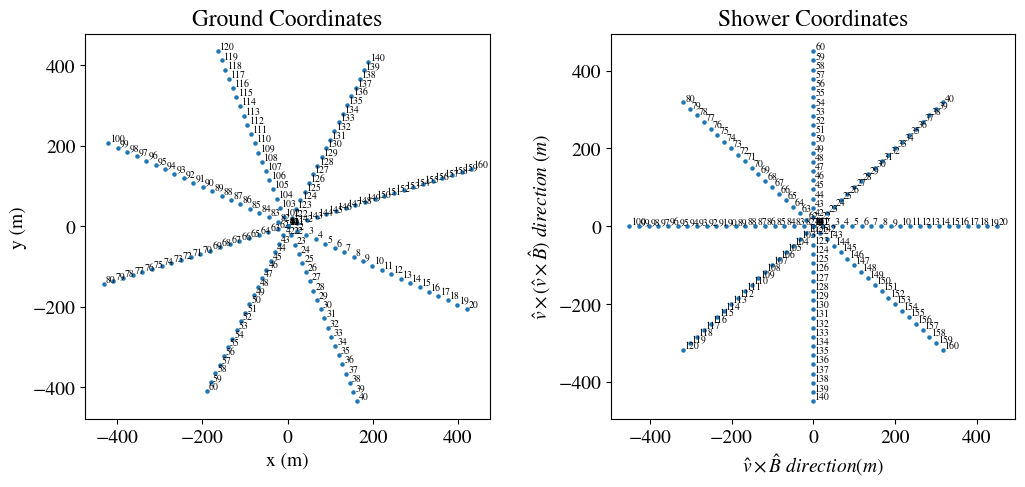

In [2]:
rmant = [label.replace("ant_", "") for label in antlabels]
vxB, vxvxB = (np.empty(160) for _ in range(2))
offset = 5
s = 5

### ground coordinate ###
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(wspace=0.3)
plot = axes[0].scatter(antx, anty, s = s)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].set_title("Ground Coordinates")

### shower coordinate ###
for i in range(len(antx)):
    g2s = GroundtoShowerCoordinates(antx[i], anty[i], [theta, phi], [Bx, By, Bz])
    new_x = g2s.vxB()
    new_y = g2s.vxvxB()
    vxB[i] = new_x
    vxvxB[i] = new_y
plot = axes[1].scatter(vxB, vxvxB, s = s)
axes[1].set_xlabel(rf"$\hat{{v}}\times\hat{{B}} \ direction (m)$")
axes[1].set_ylabel(rf"$\hat{{v}} \times (\hat{{v}}\times\hat{{B}}) \ direction \ (m)$")
axes[1].set_title("Shower Coordinates")

for i in range(len(antx)):
    axes[1].text(vxB[i] + offset, vxvxB[i] + offset, f'{rmant[i]}', fontsize=7)
    axes[0].text(antx[i] + offset, anty[i] + offset, f'{rmant[i]}', fontsize=7)

# longitudinal profile 

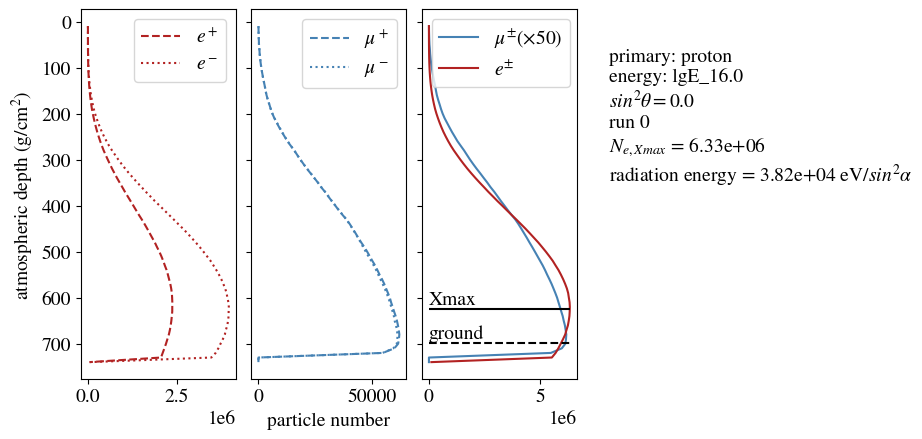

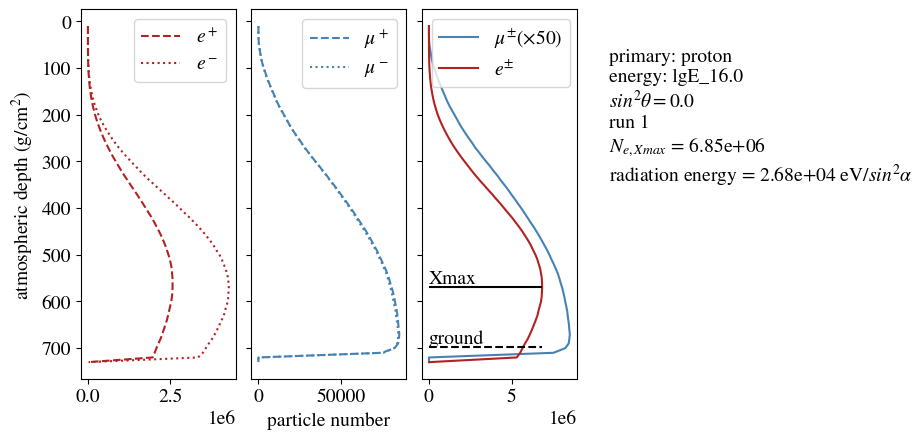

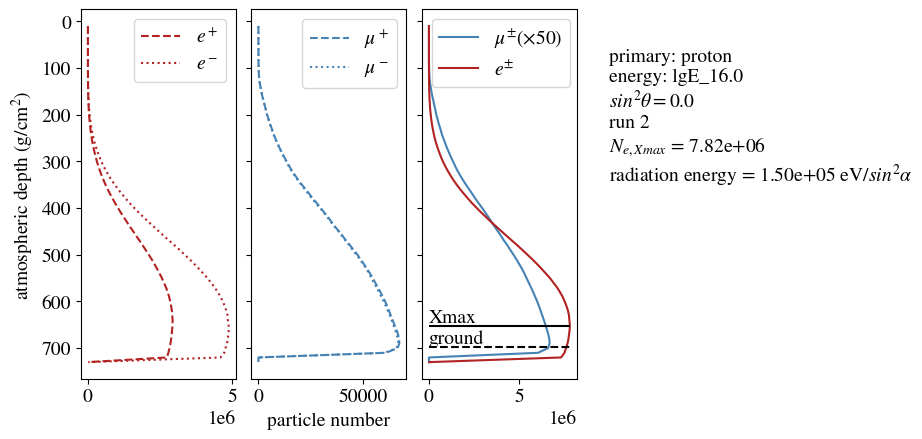

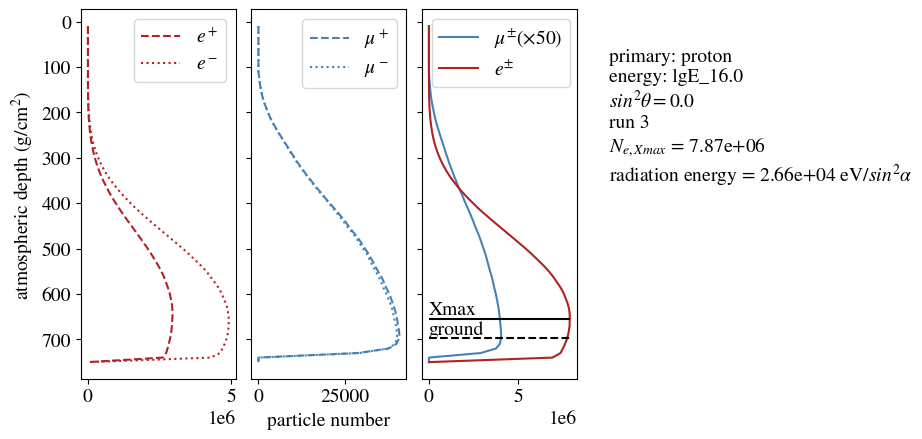

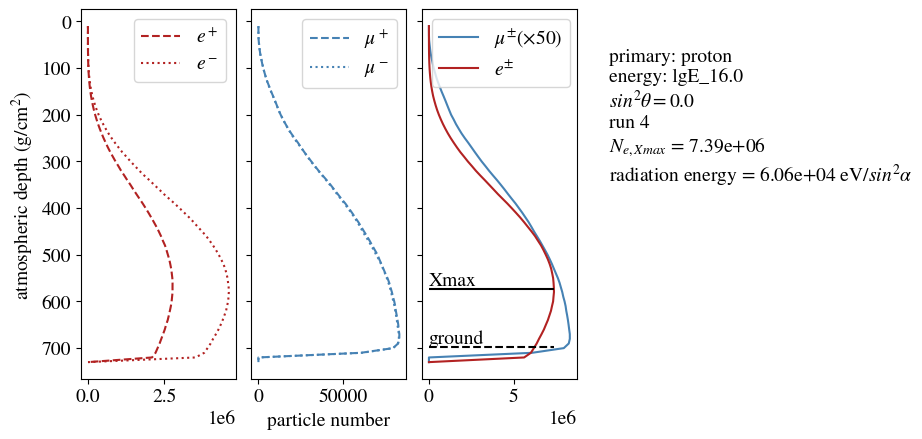

In [3]:
for runnum in range(5):
    flong = fp_long(primary, energy, sin2theta, runnum)

    # load files

    numeric_lines = []

    with open(flong) as f:
        # skip first 2 rows
        for _ in range(2):
            next(f)

        for line in f:
            try:
                # try converting all columns to float
                [float(x) for x in line.split()]
                numeric_lines.append(line)
            except ValueError:
                break  # stop at first non-numeric row

    data = np.loadtxt(StringIO("".join(numeric_lines)))
    atmdepth = data[:,0]

    # extract data
    positron = data[:,2]
    electron = data[:,3]
    tot_e = positron + electron

    muplus = data[:,4]
    muminus = data[:,5]
    tot_mu = (muplus + muminus)*50

    # Xmax data 
    fileXmax = np.loadtxt(fp_Xmax(primary, energy, sin2theta))
    Ne_Xmax = fileXmax[:,3][runnum]
    Xmax = fileXmax[:,1][runnum]

    # RadE data
    fRadE = fp_RadE_norm2(primary, energy, sin2theta)
    fileRadE = np.load(fRadE)
    RadE = fileRadE['radE(eV)'][runnum]

    # ground level
    X0 = 697.6 #g/cm^2
    thetafloat = float(sin2theta)
    costheta = np.cos(np.arcsin(np.sqrt(thetafloat)))
    Xv = X0/ costheta

    # plot
    pltlp(atmdepth, positron, electron, muplus, muminus, tot_e, tot_mu, Xmax, Ne_Xmax, RadE, runnum, Xv)

# particle distributions

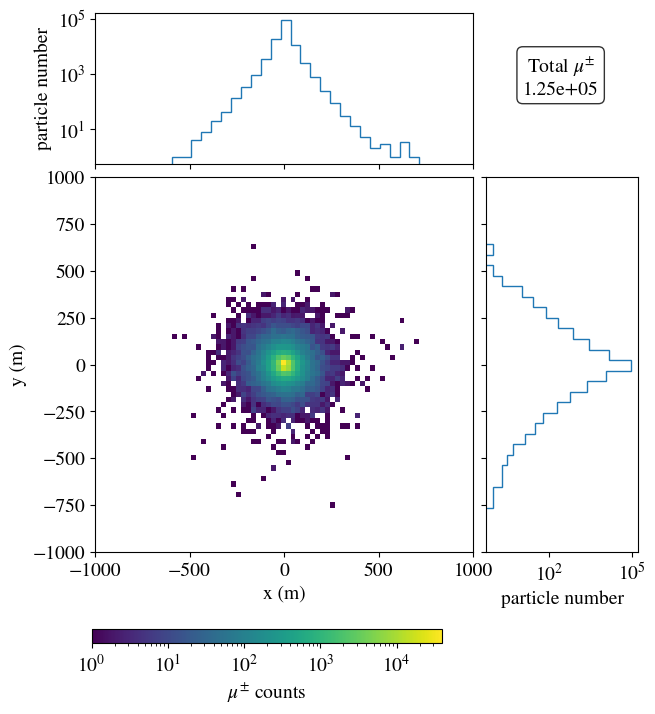

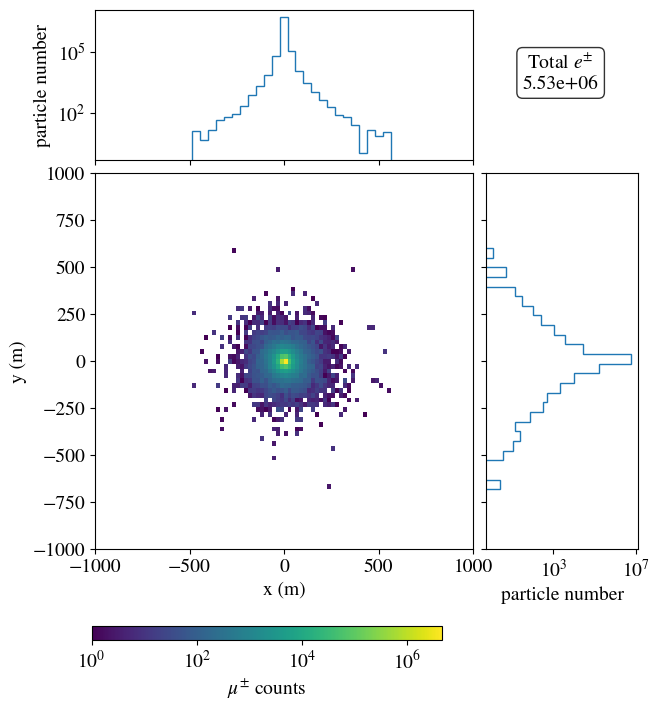

In [4]:
pltNpar(mux, muy, w_mu, 'muon')
pltNpar(ex, ey, w_e, 'electron')

# Nmu, Ne correlation

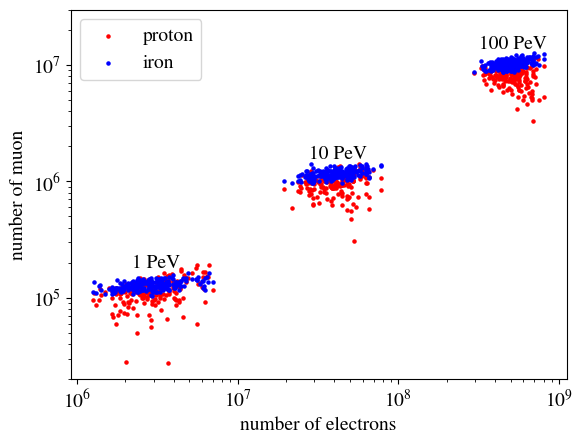

In [5]:
energies = [16.0, 17.0, 18.0] ## Energy logE 
energylabel = ["1 PeV", "10 PeV", "100 PeV"]
sin2theta = 0.4
for i in range (len(energies)):
    energydir = f'lgE_{energies[i]}'
    
    labels = energylabel[i]
    pltmuecorr(energydir, sin2theta, labels)

# Energy radiation with bandpass filter

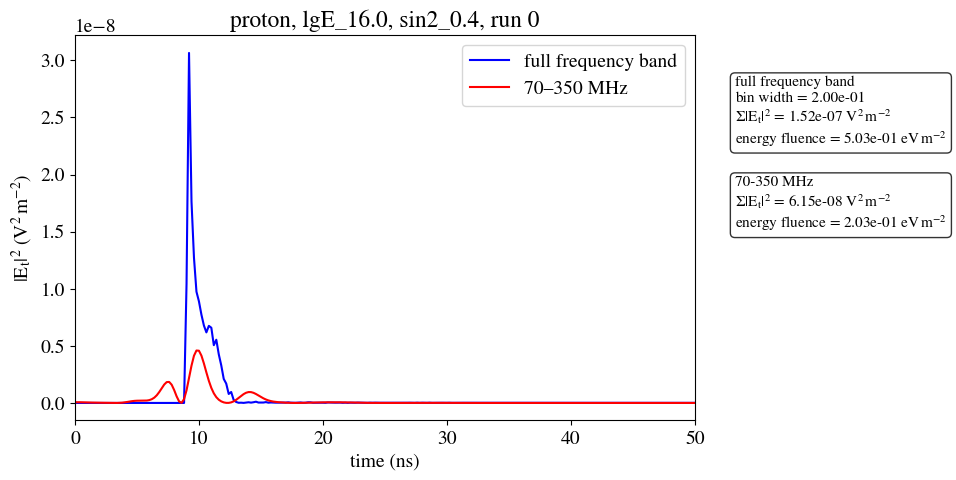

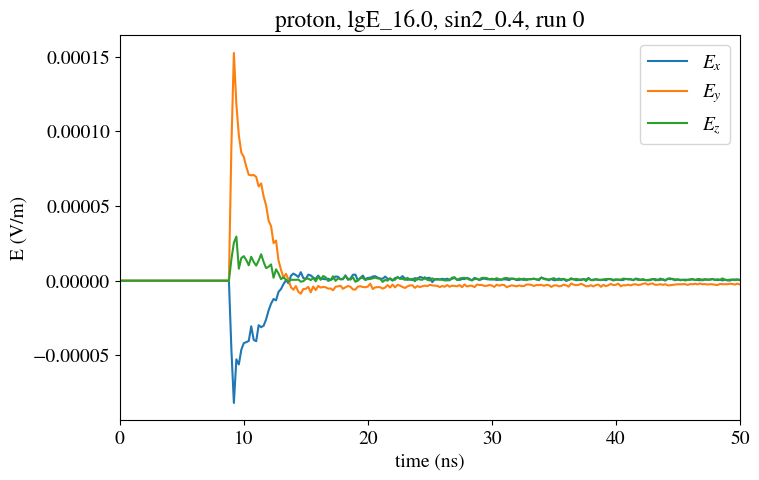

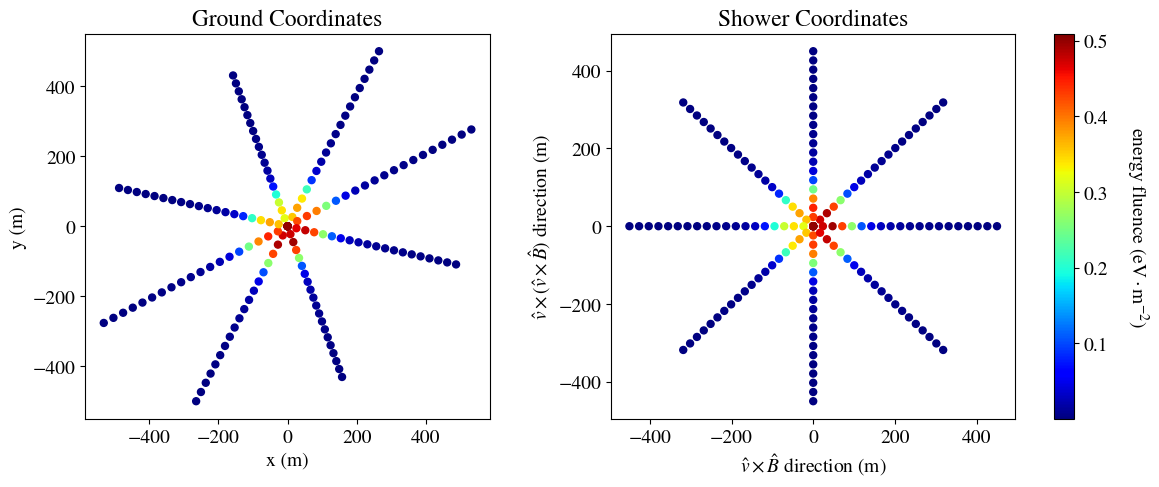

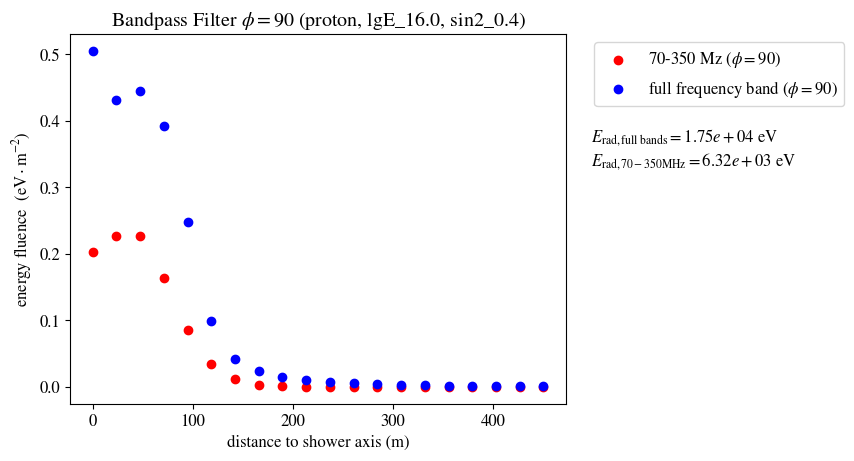

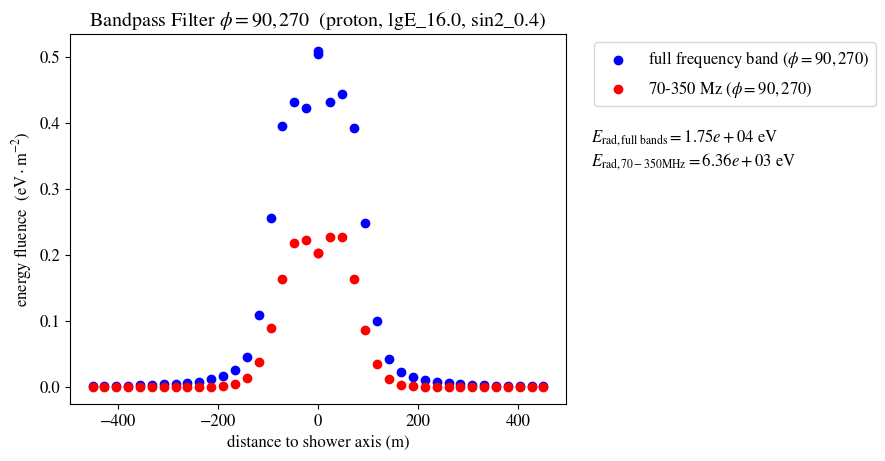

(40, 40)

In [2]:
Nant = 160 #number of total antennas
# create empty arrays of energy fluence, filtered energy fluence, vxB, and vxvxB
ef, eff, vxB, vxvxB = (np.empty(Nant) for _ in range(4))


# 160 antenna (Nant = 160) loop
for i, ant_no in enumerate(range (1,Nant+1)):
    
    radio_dat = np.loadtxt(fp_radio(primary, energy, sin2theta, runnum, ant_no))

    # extract data
    time = radio_dat[:,0]*1e9
    E_SI = 29979 # electric field converter from cgs unit to SI unit 1 statV/cm≈29,979 V/m
    Ex, Ey, Ez = radio_dat[:,1]*E_SI, radio_dat[:,2]*E_SI, radio_dat[:,3]*E_SI # north, west, vertical electric field in V/m

    #filter electric field using signal.butter
    b, a = signal.butter(5, [70e6, 350e6] , 'bp', fs=5e9)
    Ex_f, Ey_f, Ez_f = (signal.filtfilt(b, a, i) for i in (Ex, Ey, Ez))

    # |E|^2 raw and filtered
    Emag2, Emag2_f = magE2(Ex, Ey, Ez), magE2(Ex_f, Ey_f, Ez_f) 

    # sum(|E|^2)
    E_sum, E_sum_f = sum(Emag2), sum(Emag2_f)
     
    # energy fluence 
    ef[i], eff[i] = energyfluence(E_sum), energyfluence(E_sum_f)

    # plot |E|^2 histogram for antenna number 1 
    if ant_no == 1:
        pltEmag2(ant_no, time, time, Emag2, Emag2_f, E_sum, E_sum_f, 'bp')
        pltE(ant_no, time, Ex,Ey, Ez)
        
# plot energy fluence map choose weather colors = ef or colors = eff
pltefmap(finp, Nant, vxB, vxvxB, antx, anty, ef)
# plot radius vs energy fluence
xmin, xmax = -500, 500
pltef(vxB, vxvxB, ef, eff, 'bp', xmin, xmax, 'linear', primary, energy, sin2theta)

# Energy radiation with FFT

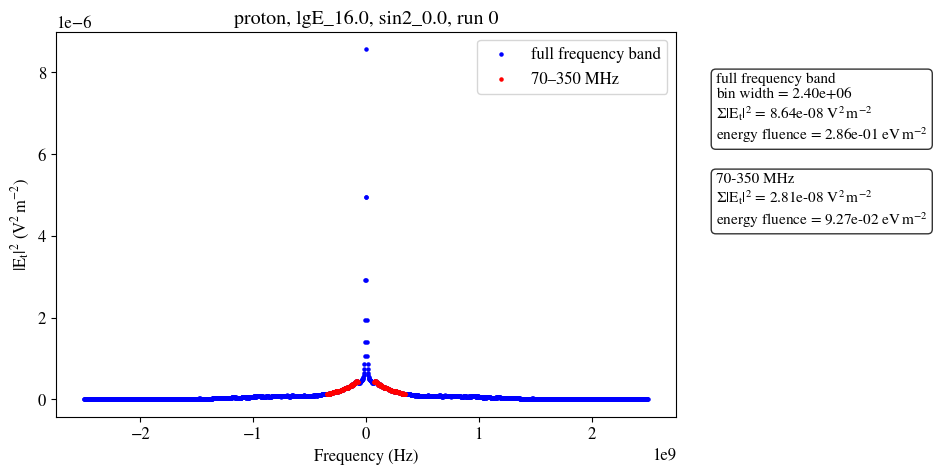

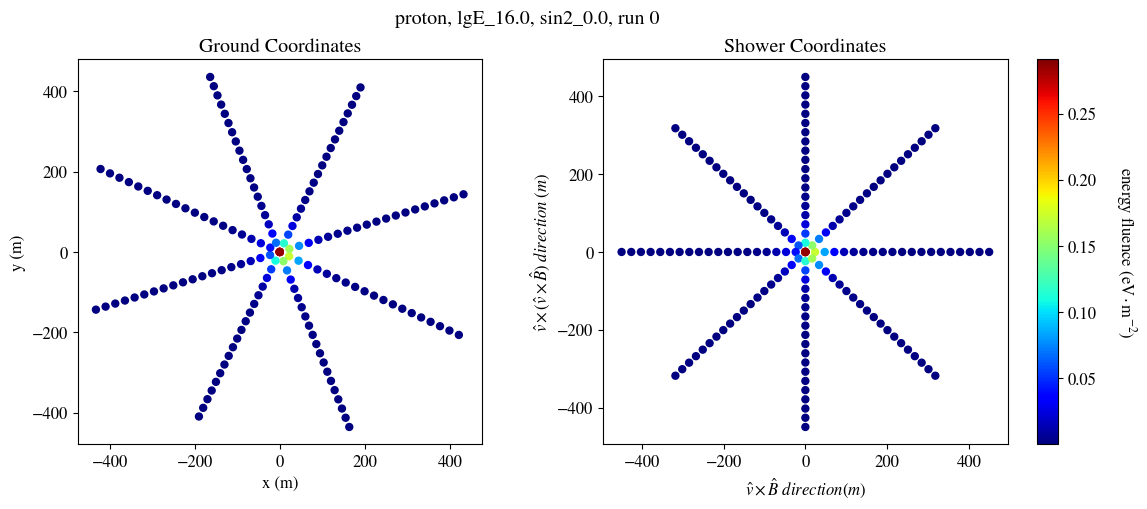

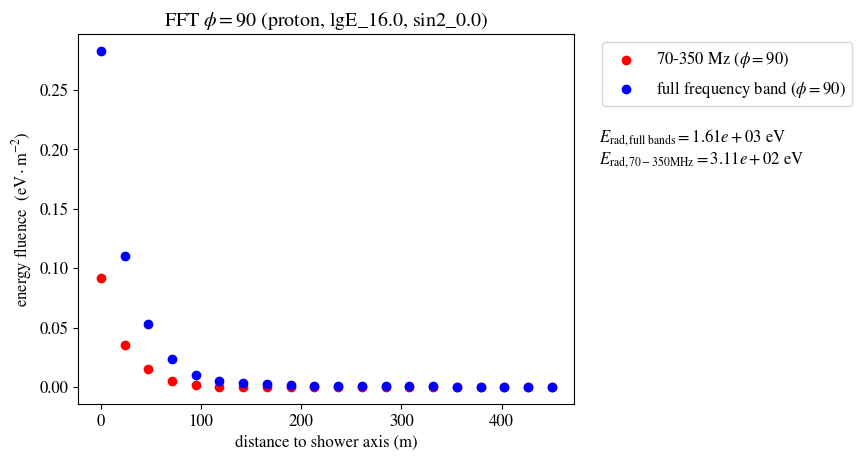

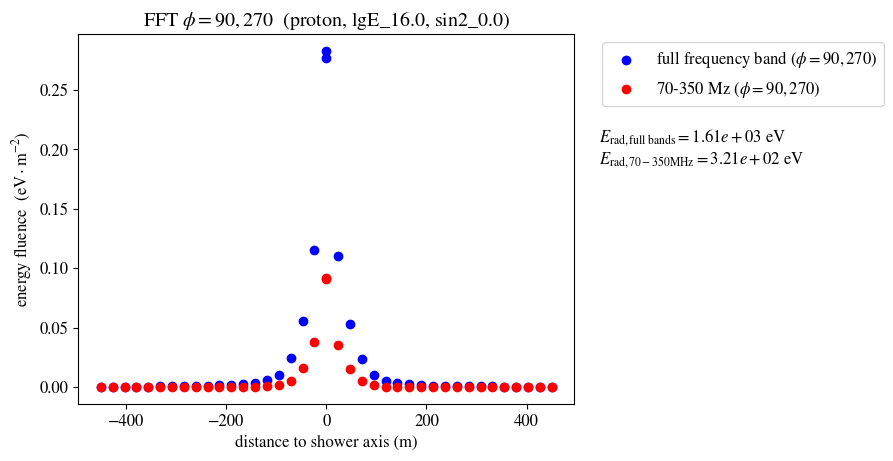

(40, 40)

In [4]:
Nant = 160 #number of total antennas
# create empty arrays of energy fluence, filtered energy fluence, vxB, and vxvxB
ef, eff, vxB, vxvxB = (np.empty(Nant) for _ in range(4))

fmin,fmax = 70e6, 350e6 # frequency range 70-350 MHz

# 160 antenna (Nant = 160) loop
for i, ant_no in enumerate(range (1,Nant+1)):
    
    radio_dat = np.loadtxt(fp_radio(primary, energy, sin2theta, runnum, ant_no))

    # extract data
    time = radio_dat[:,0]
    E_SI = 29979 # electric field converter from cgs unit to SI unit 1 statV/cm≈29,979 V/m
    Ex, Ey, Ez = radio_dat[:,1]*E_SI, radio_dat[:,2]*E_SI, radio_dat[:,3]*E_SI # north, west, vertical electric field in V/m
    Er = np.sqrt(Ex**2 + Ey**2 + Ez**2) 

    # FFT
    dt = time[1] - time[0]
    N  = len(time)
    Efft = fft.fft(Er) # real valued signal, use rfft
    freq = (np.fft.fftfreq(N, dt))

    Efft2 = abs(Efft)**2
    E_sum = fftsum(N, Efft2)

    # restrict energy range
    mask = (abs(freq) >= fmin) & (abs(freq) <= fmax)
    Efft2_mask = abs(Efft[mask])**2
    freq_f = freq[mask]
    E_sum_f = fftsum(N, Efft2_mask)

    # energy fluence 
    ef[i], eff[i] = energyfluence(E_sum), energyfluence(E_sum_f)

    # plot |E|^2 histogram for antenna number 1 
    if ant_no == 1:
        pltEmag2(ant_no, freq, freq_f, Efft2, Efft2_mask, E_sum, E_sum_f, 'fft')

# plot energy fluence map choose weather colors = ef or colors = eff
pltefmap(finp, Nant, vxB, vxvxB, antx, anty, ef)

# plot radius vs energy fluence
# pltef(vxB, vxvxB, ef, eff, 'fft')
xmin, xmax = -500, 500
# pltef(vxB, vxvxB, ef, eff, 'fft', xmin, xmax, 'log')
pltef(vxB, vxvxB, ef, eff, 'fft', xmin, xmax, 'linear', primary, energy, sin2theta)

# Ne vs. Radiation Energy

## NeGround vs Radiation Energy

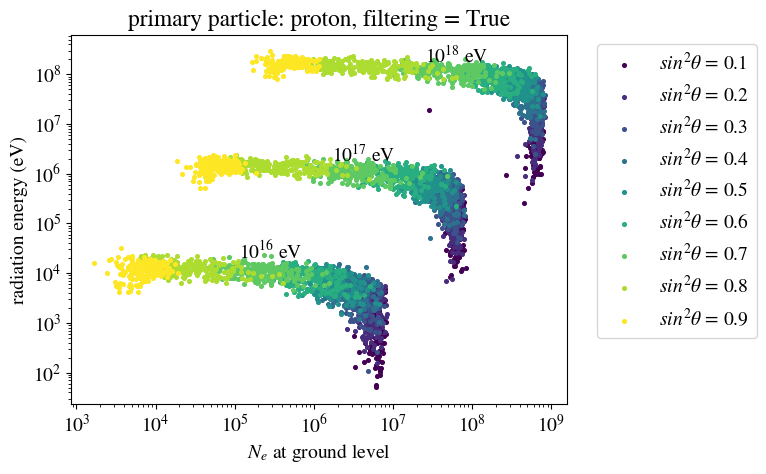

In [ ]:
sin2thetas = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7",  "0.8", "0.9"]
primary = ["proton"]
energy = ["lgE_16.0", "lgE_17.0","lgE_18.0"]
labels = [rf'$10^{{16}}$ eV', rf'$10^{{17}}$ eV', rf'$10^{{18}}$ eV']
filtering = True
norm = False
pltRadE_NeGround(sin2thetas, primary, energy, labels, norm = norm, filtering = filtering)

## NeXmax vs Radiation Energy

FileNotFoundError: Xmax/proton_lgE_18.0_sin2_0.1.dat not found.

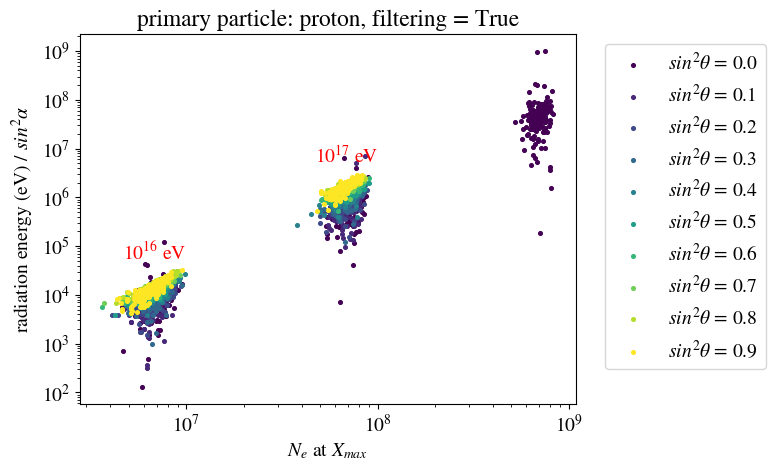

In [8]:
sin2thetas = ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7",  "0.8", "0.9"]
primary = ["proton"]
energy = ["lgE_16.0", "lgE_17.0", "lgE_18.0"]
labels = [rf'$10^{{16}}$ eV',rf'$10^{{17}}$ eV', rf'$10^{{18}}$ eV']
norm = True
filtering = True
pltRadE_NeXmax(sin2thetas, primary, energy, labels, norm = norm, filtering = filtering)

## Ne ratio vs Xmax

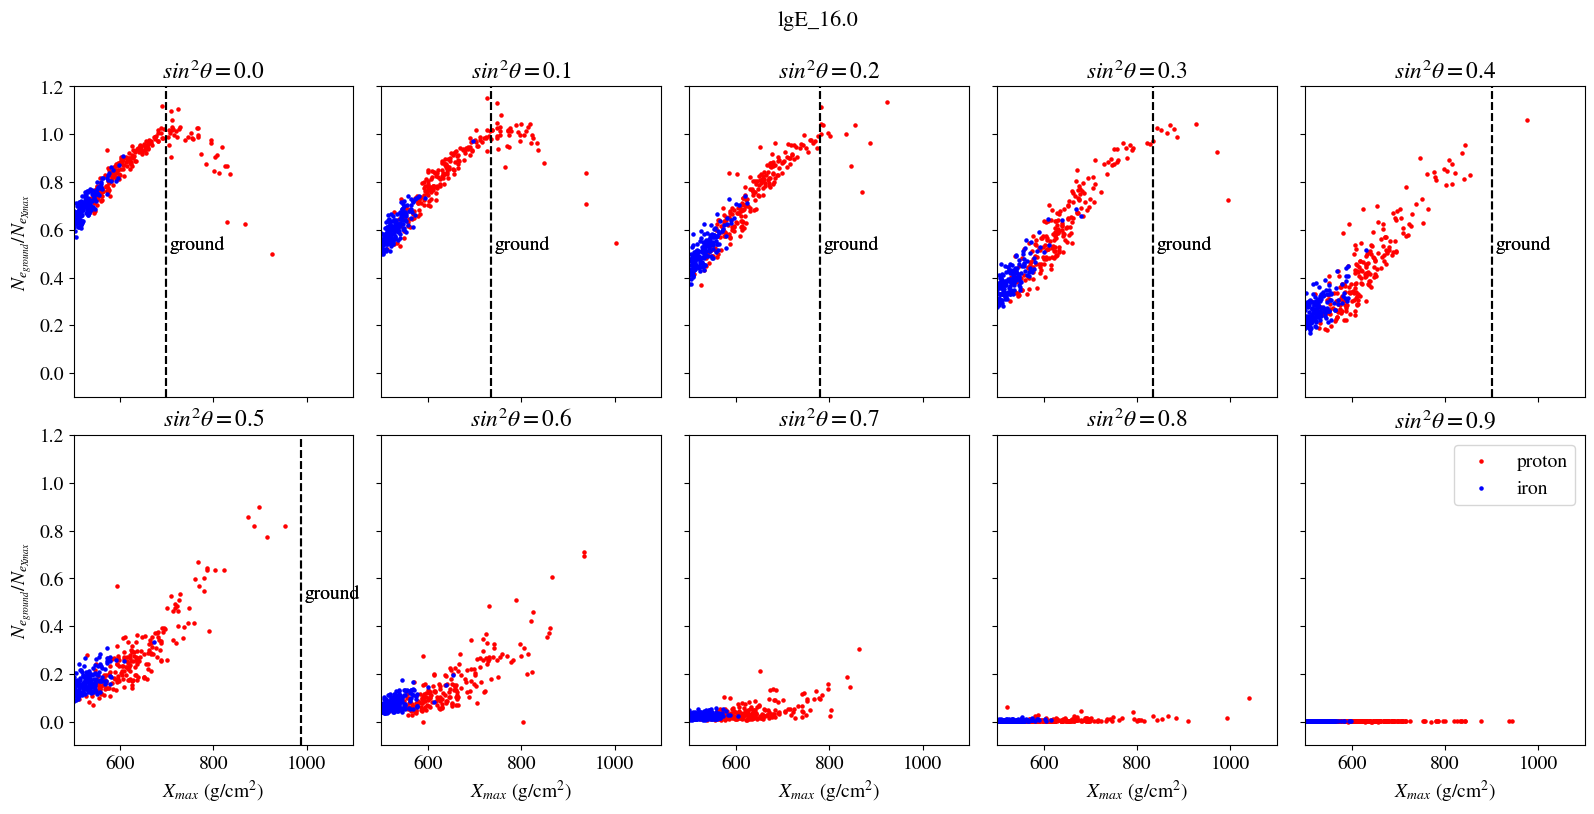

In [4]:
energy = ["lgE_16.0"]
pltNeRatio(energy,style = 'horiz') # style = 'horiz' or style = 'verti'

## Ne,Xmax vs Xmax vs Radiation Energy

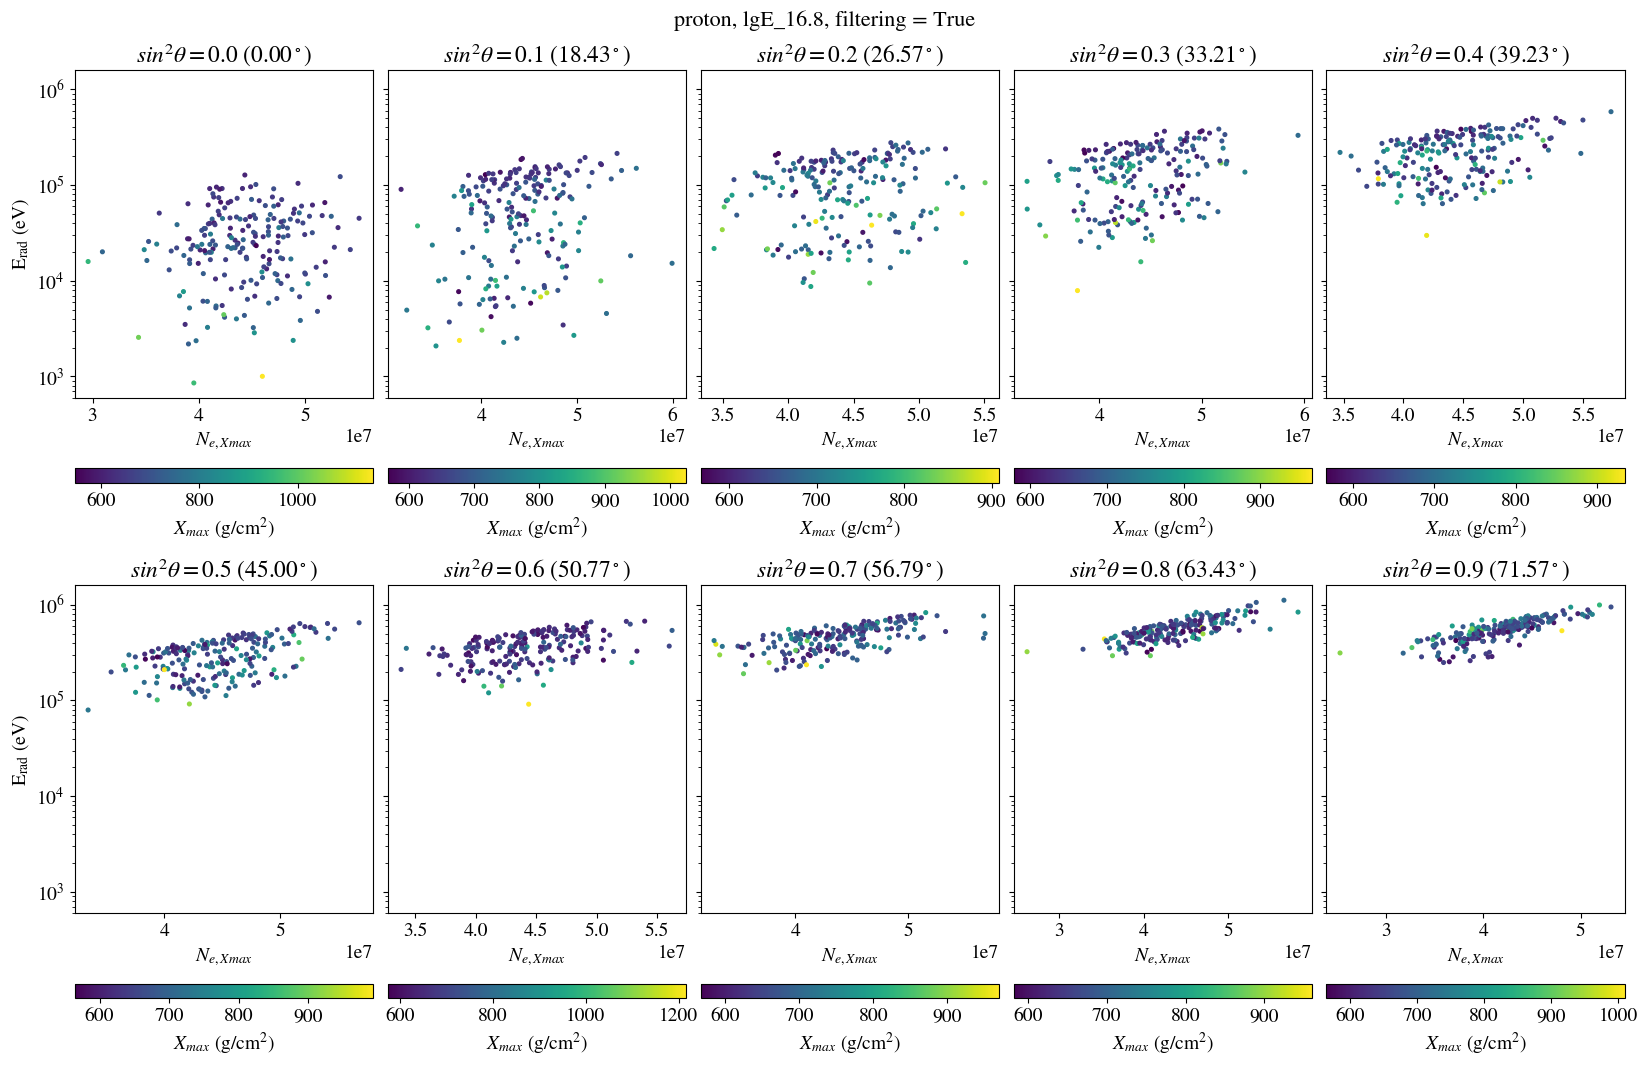

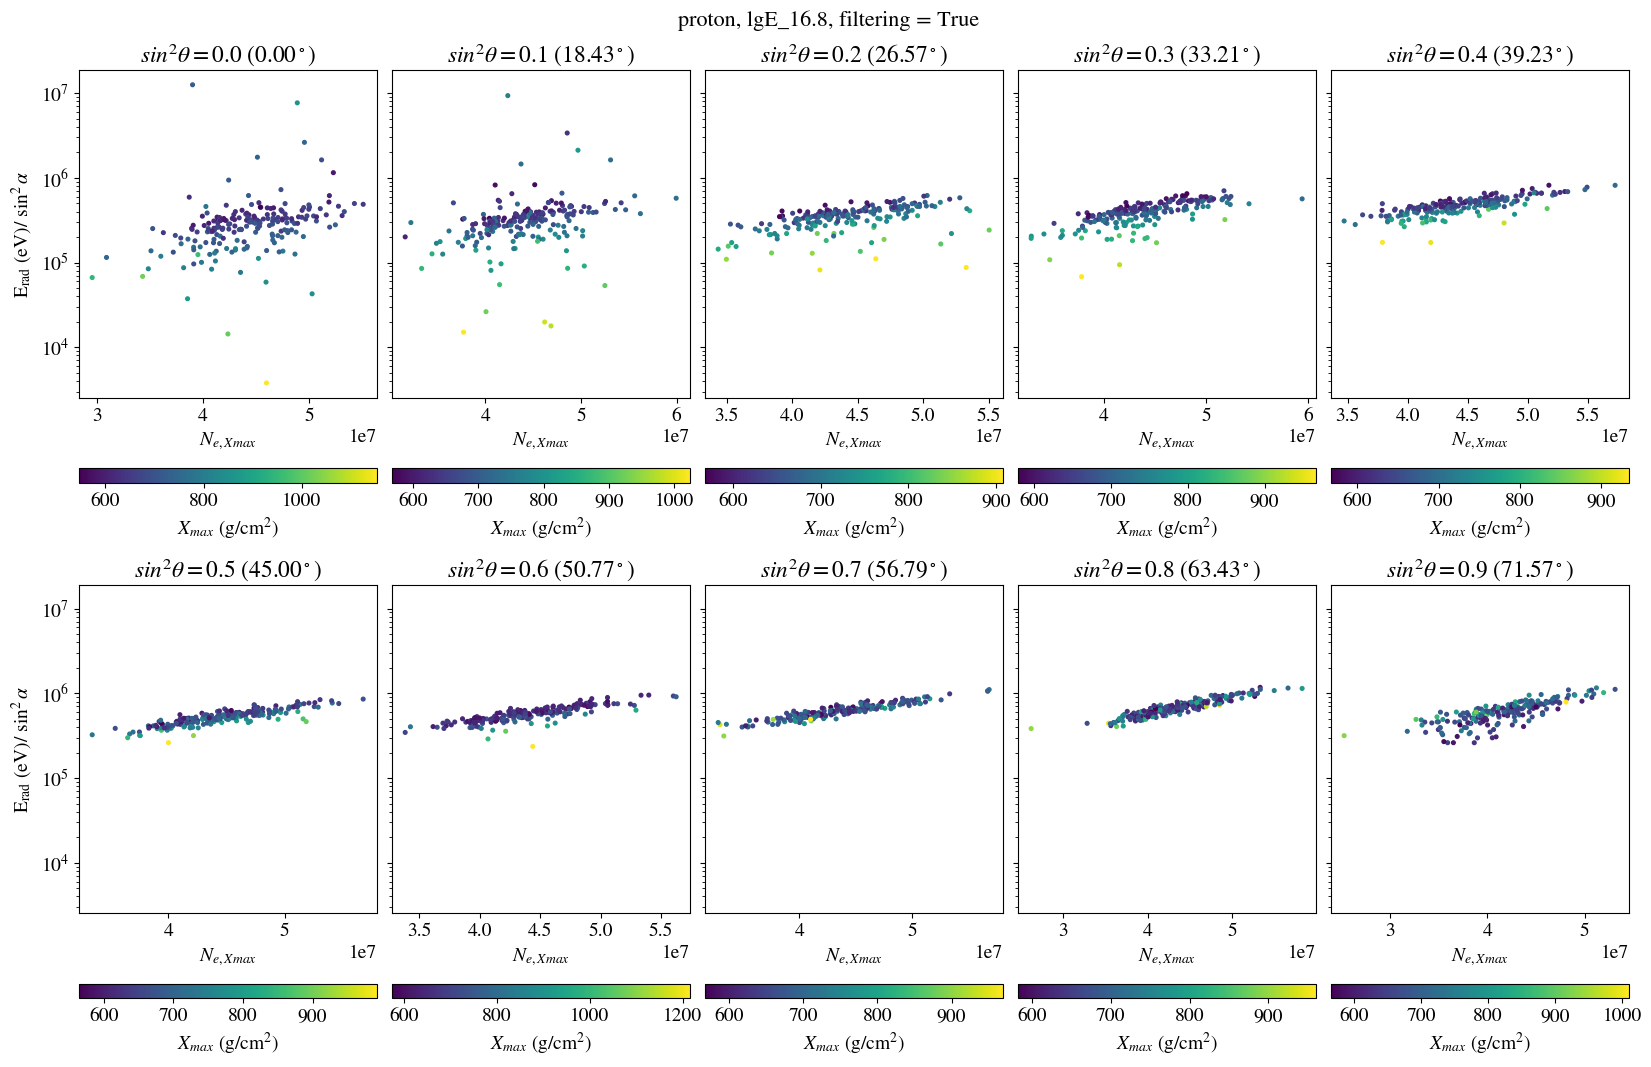

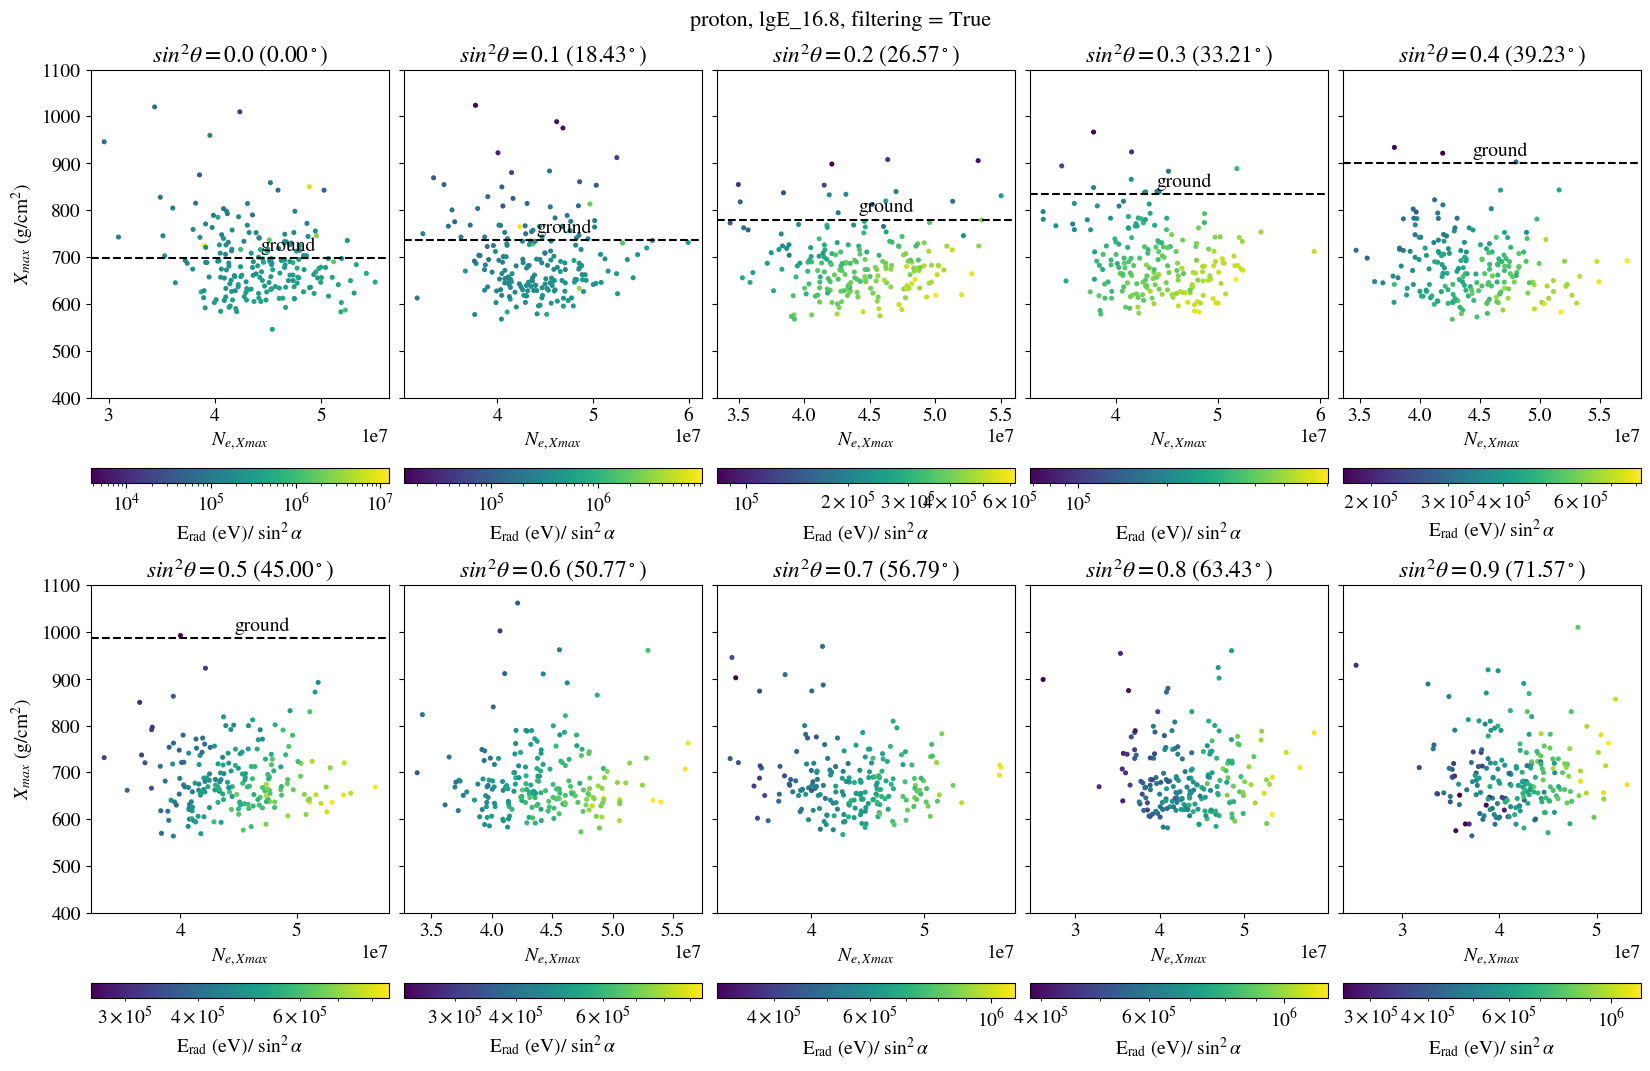

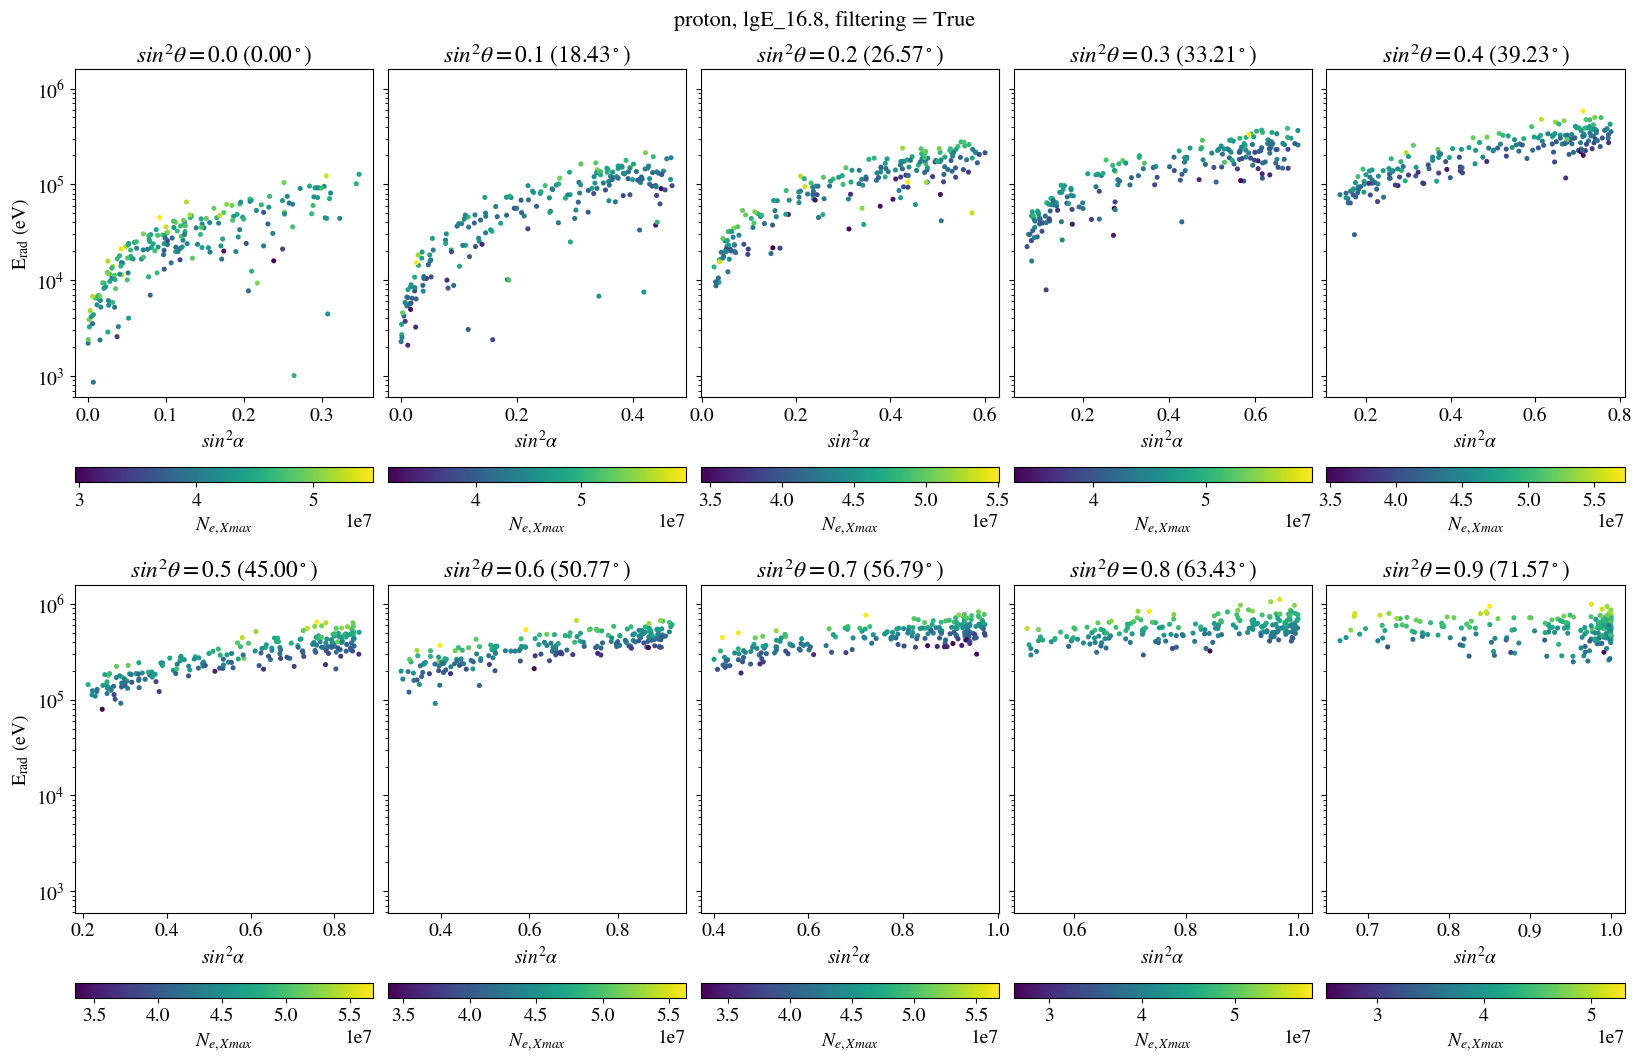

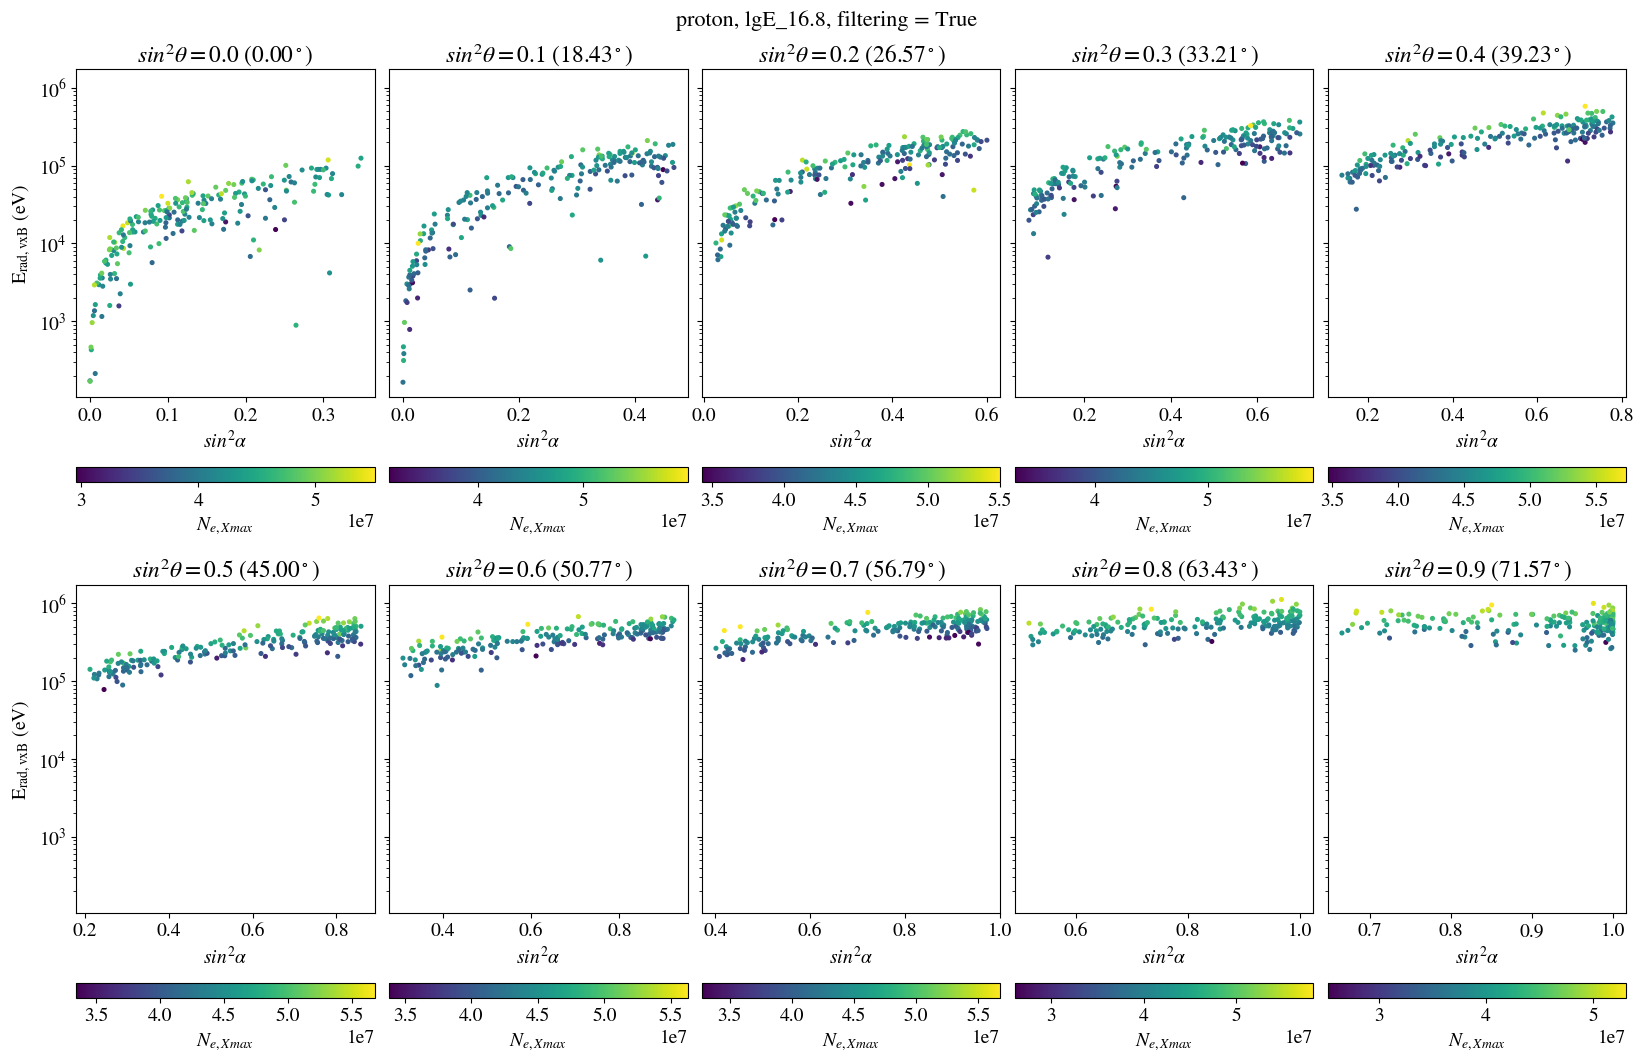

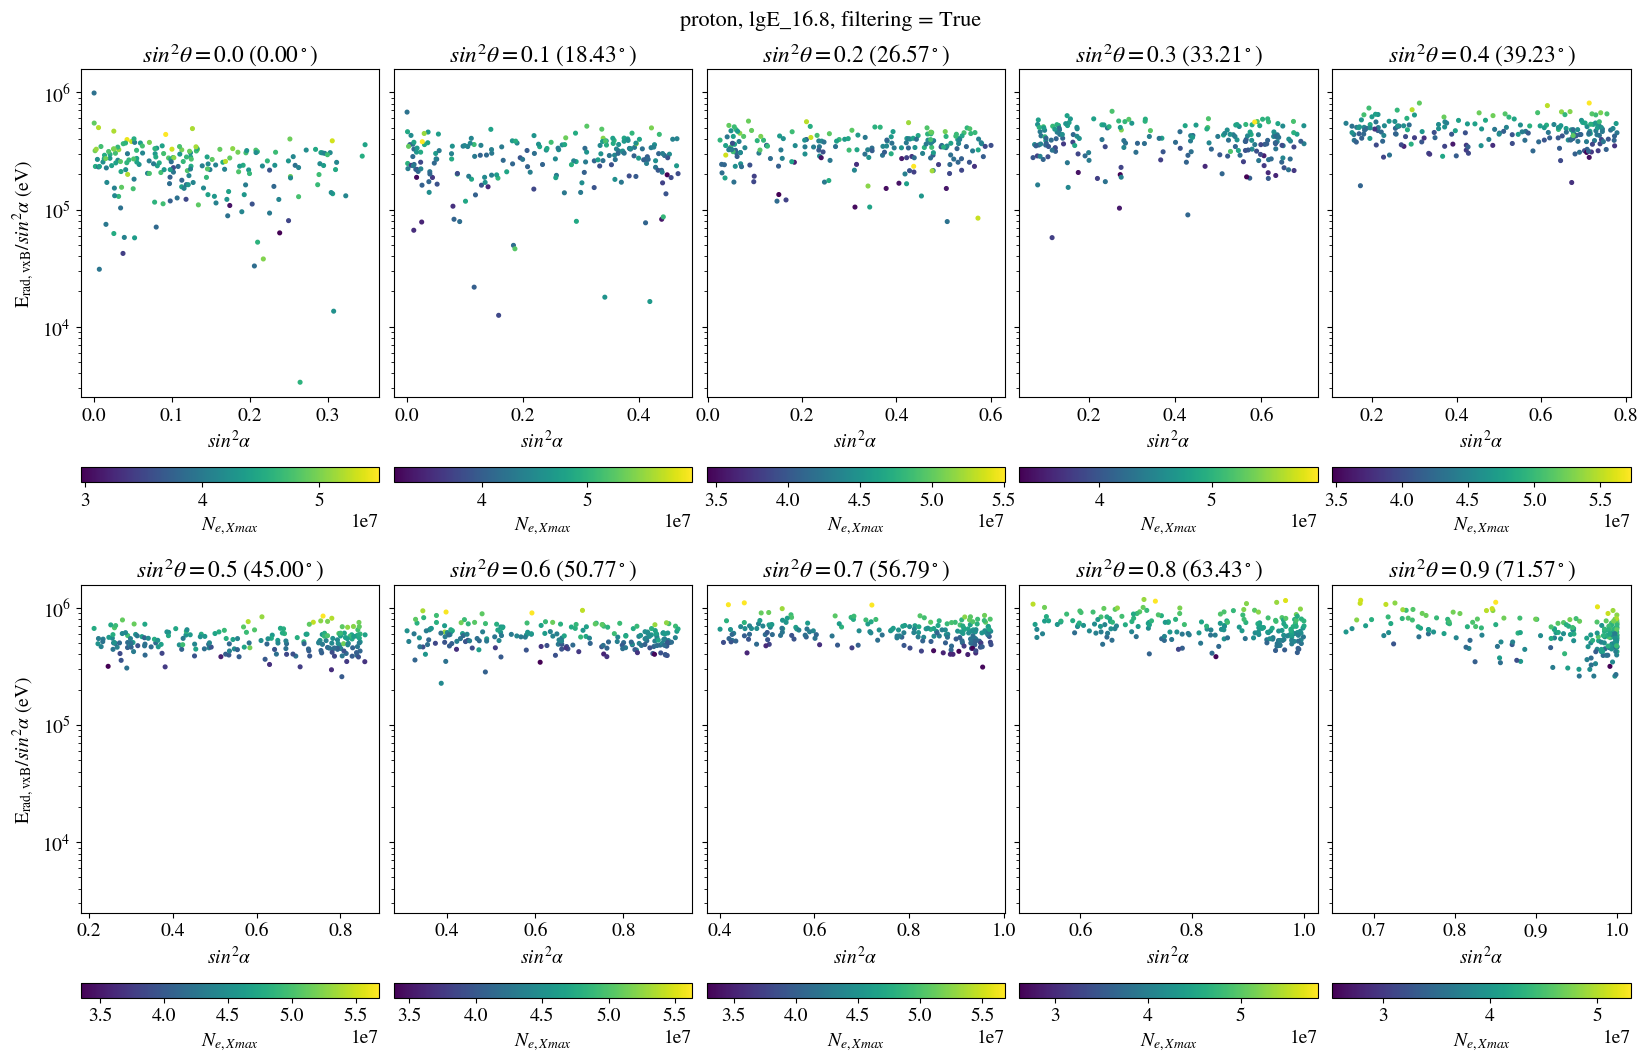

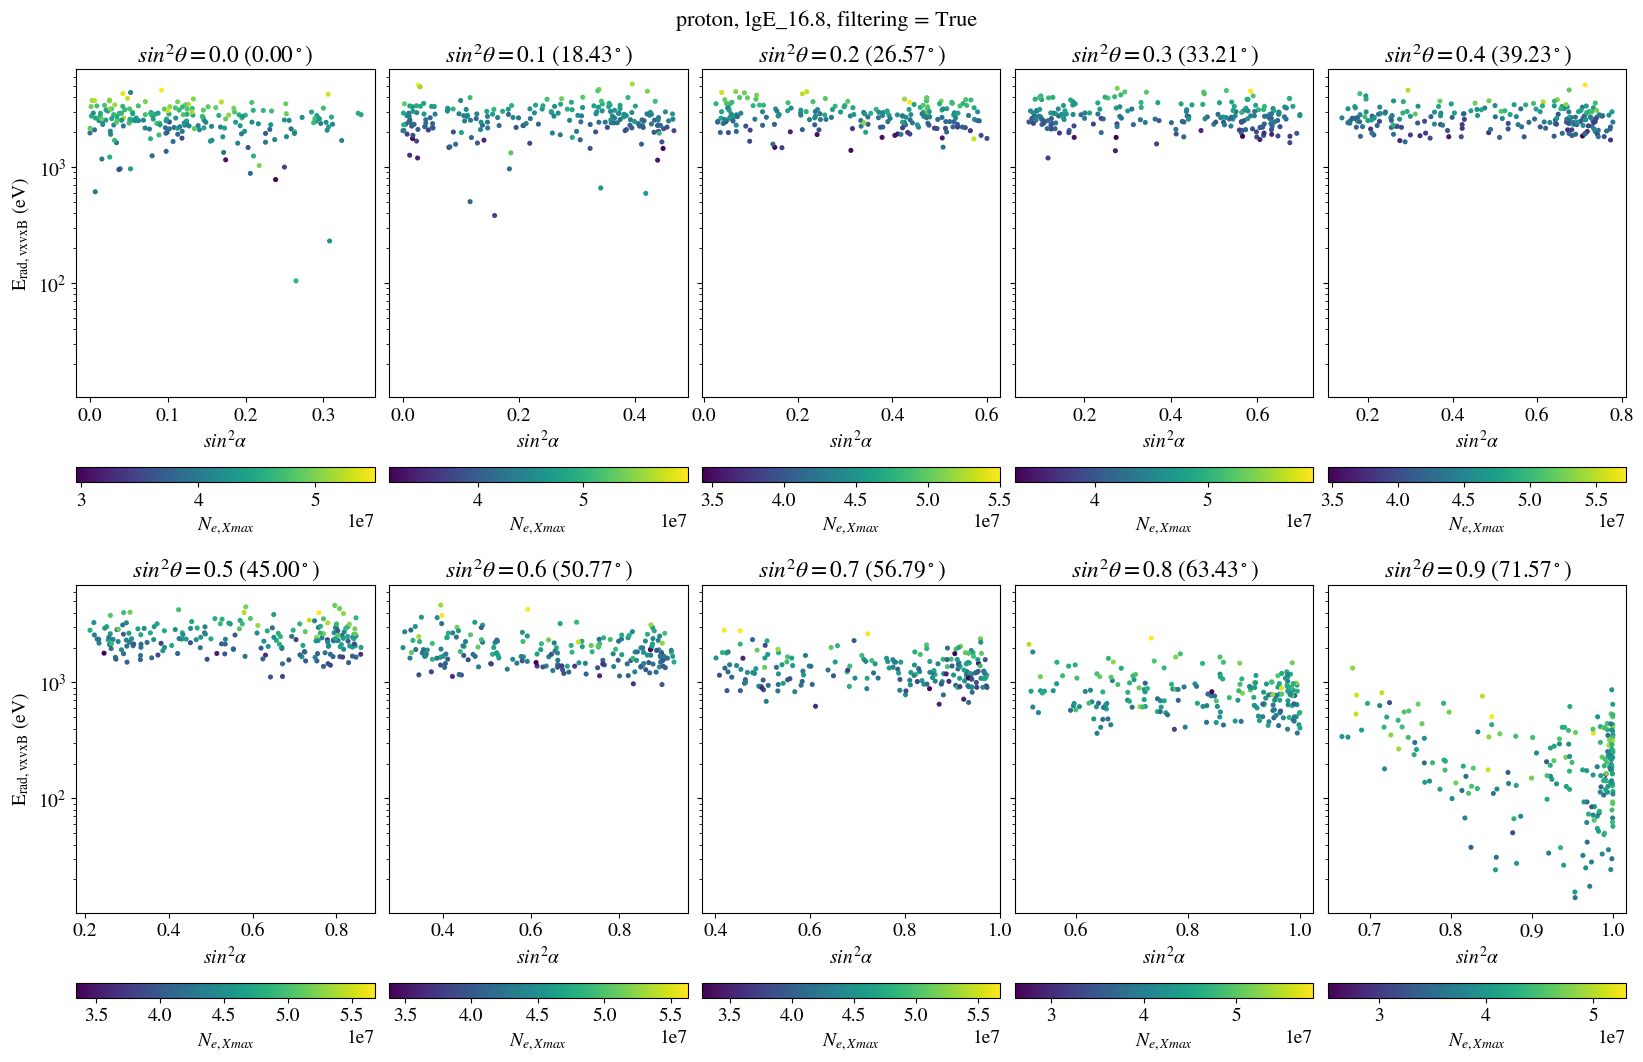

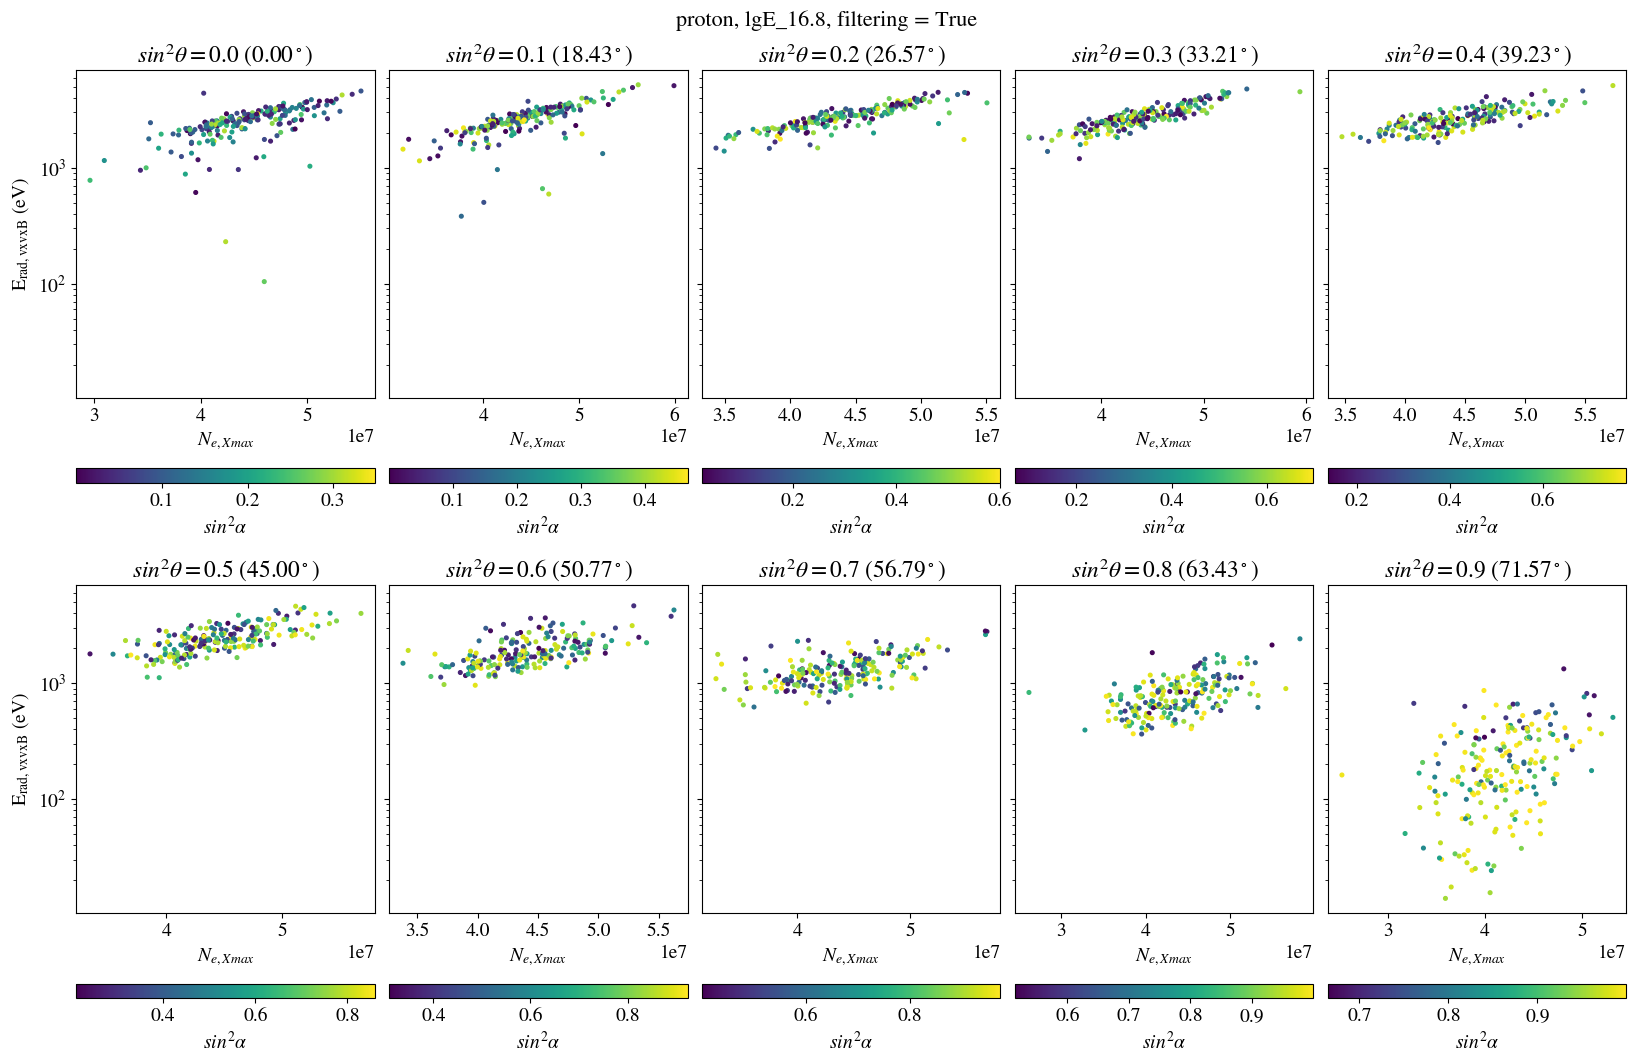

In [3]:
primary = ["proton"]
energy = ['lgE_16.8']
style = 'horiz'
corr =['NeErad', 'NeErad_norm', 'NeXmax', 'EradSina', 'EvxBsina', 'EvxBsina_norm', 'EvxvxBsina', 'EvxvxBNe']
filtering = True
for i in corr:
    pltNeXmaxRadEAllzenith(primary, energy, filtering, style=style, corr=i)

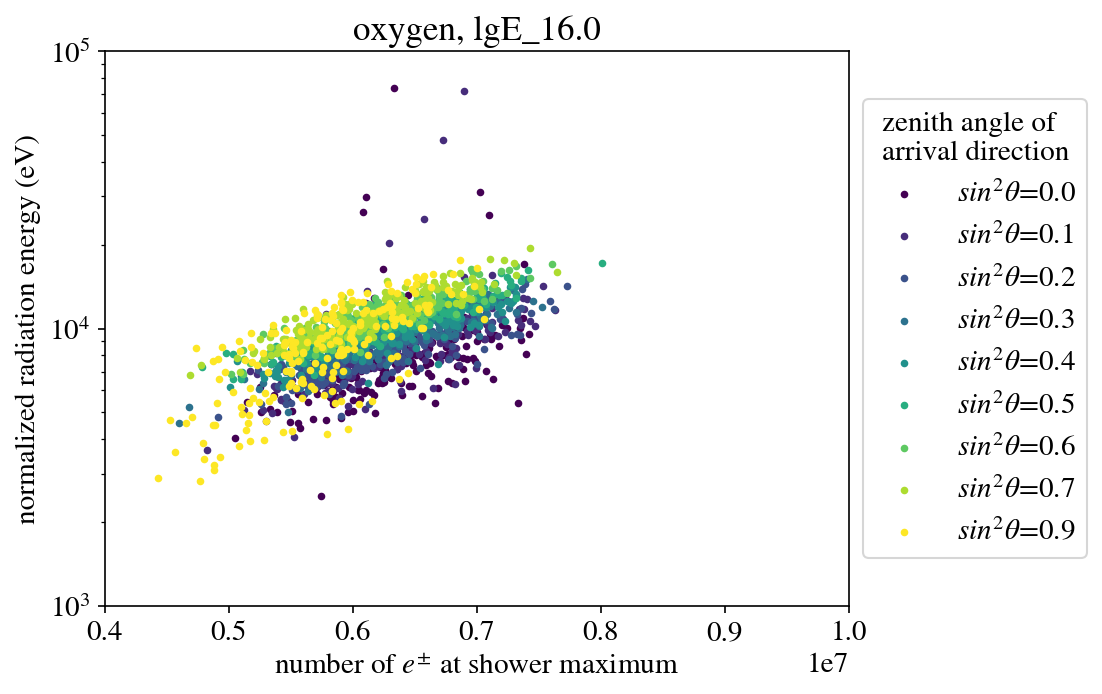

In [4]:
sin2thetas = ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.9"]
p = 'oxygen'
e = 'lgE_16.0'
colors = plt.cm.viridis(np.linspace(0, 1, len(sin2thetas)))
X0 = 697.6

fig, ax = plt.subplots(dpi = 150)

for i, sin2theta in enumerate(sin2thetas):          
    fXmax = fp_Xmax(p, e, sin2theta)
    fRadE = fp_RadE_norm2(p, e, sin2theta)

    fileXmax = np.loadtxt(fXmax)
    Ne = fileXmax[:,5]
    Xmax = fileXmax[:,6]

    fileRadE = np.load(fRadE, allow_pickle=True)
    RadE = fileRadE['radE_filtered(eV)']

    alpha = fileRadE['alpha']
    sin2alpha = np.sin(alpha)**2
    thetafloat = float(sin2theta)
    theta = np.arcsin(np.sqrt(thetafloat))
    costheta = np.cos(theta)

    Xv = X0/ costheta


    Ne_filt = []
    RadE_filt = []
    for j in range (len(Xmax)):
        if Xmax[j] <= Xv:
            Ne_filt.append(Ne[j])
            RadE_filt.append(RadE[j])
        else: pass
    ax.scatter(Ne_filt, RadE_filt, s=7, color=colors[i], label=rf'$sin^2 \theta$={sin2theta}')

ax.set_title(f'{p}, {e}')
ax.set_yscale('log')
ax.set_ylim(1e3, 1e5)
ax.set_xlim(0.4e7,1e7)
ax.set_ylabel('normalized radiation energy (eV)')
ax.set_xlabel(r'number of $e^{\pm}$ at shower maximum')

# ax.legend()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='zenith angle of' +'\n'+ 'arrival direction')
plt.show()

# Scintillator Response

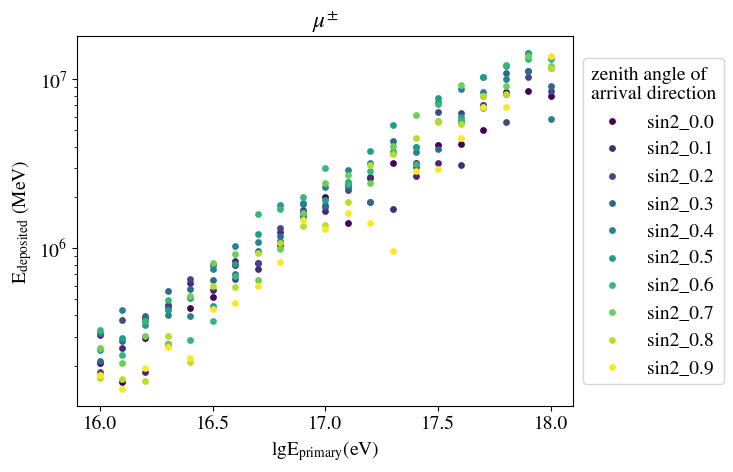

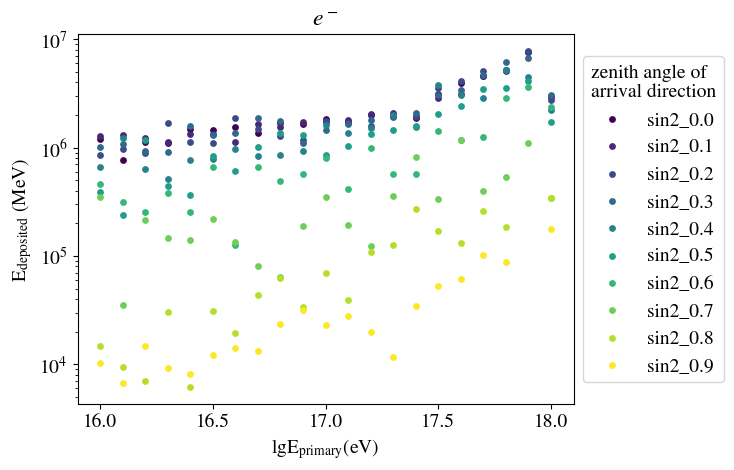

In [ ]:
sin2thetas = [f"sin2_{x/10:.1f}" for x in range(0, 10)] # zenith bin sin2_0.0, sin2_0.1, ..., sin2_0.9
colors = plt.cm.viridis(np.linspace(0, 1, len(sin2thetas)))

fig1, ax1 = plt.subplots() 
fig2, ax2 = plt.subplots()

ylabel = rf'$\mathrm{{E_{{deposited}}}}$ (MeV)'
xlabel = rf'$\mathrm{{lgE_{{primary}}(eV)}}$'
for i in range (len(sin2thetas)):

    fileScint = f'ScintillatorResponse/TotalEdep/{sin2thetas[i]}.npz'
    f = np.load(fileScint)

    energy = f['energy']
    Edep_mu = f['Edep_mu']
    Edep_e = f['Edep_e']

    ax1.scatter(energy, Edep_mu, s=15 , color=colors[i],label=rf'{sin2thetas[i]}')
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='zenith angle of' +'\n'+ 'arrival direction')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax1.set_yscale('log')
    ax1.set_title(rf'$\mu^{{\pm}}$')

    ax2.scatter(energy, Edep_e, s=15 , color=colors[i],label=rf'{sin2thetas[i]}')
    ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='zenith angle of' +'\n'+ 'arrival direction')
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(ylabel)
    ax2.set_yscale('log')
    ax2.set_title(rf'$e^-$')


